# Chapter 11: Quantum Noise

Quantum hardware is far from perfect. Gates can produce noisy results — an ideal $X|0\rangle=|1\rangle$ may instead yield $\sqrt{F_1}\,|1\rangle+\sqrt{1-F_1}\,|0\rangle$ — and qubit states decohere over time. On today's Noisy Intermediate-Scale Quantum (NISQ) devices, single-qubit gates have fidelity $F_1\approx0.999$ and two-qubit gates $F_2\approx0.99$, versus classical error rates near $10^{-15}$. Along a circuit path the fidelities compound as $F_\text{circuit}=(F_1)^{n_1}(F_2)^{n_2}$, so accuracy degrades rapidly with depth — this is the defining constraint of the NISQ era.

This notebook simulates hardware noise in Qiskit. We inject errors with a noise model on the `AerSimulator` and study three effects: single- and two-qubit **gate infidelity** (an $X$ gate, then a Bell state), the way **circuit depth** erodes state-preparation fidelity, and **readout error** at measurement. (The code uses Qiskit's depolarizing channel, a more general model than the book's bit-flip picture but with the same fidelity-loss message.) Error correction and mitigation are surveyed at the end.

---

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions
- Chapter 9 (Quantum Circuits) for circuit depth/size and CNOT-based entanglement

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from Chapter08_QuantumGates_functions import simulate_measurements,runCircuitOnIBMQuantum

## Simulating hardware noise  *(Book §11.2)*

Running on real hardware is expensive, so Qiskit provides noise models that emulate realistic devices. We attach a channel to the simulated gates so that each gate performs its intended operation with probability $F=1-p$ and fails with probability $p$, tying the error rate directly to the gate fidelity. The examples below build up from a single gate to entangling circuits and deeper state preparation.

### Example 1: single $X$ gate  *(Book §11.1–11.2, Example 11.3)*

We apply an $X$ gate to $|0\rangle$ under a noise channel with single-qubit error rate $p_1=1-F_1=0.001$. Ideally $X|0\rangle=|1\rangle$ so $P(|1\rangle)=1$; with noise the gate occasionally fails and $P(|1\rangle)\approx F_1=0.999$. A typical result is `{'1': ~9989, '0': ~11}` — the small $|0\rangle$ fraction is exactly the modeled fidelity loss.

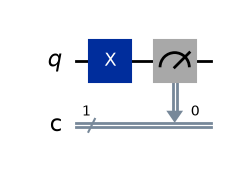

Counts: {'1': 9995, '0': 5}
P(1): 0.9995


In [2]:
p1 = 1 - 0.999   # single-qubit error rate
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p1, 1), ['x'])

qc = QuantumCircuit(1, 1)
qc.x(0)
qc.measure(0, 0)
display(qc.draw('mpl'))
nShots = 10000
counts = simulate_measurements(qc, shots=nShots, noise_model=noise_model)    
print('Counts:', counts)
print('P(1):', counts.get('1', 0) / nShots)

### Example 2: Bell state under noise  *(Book §11.2, Example 11.4)*

The Bell state $|\Phi^+\rangle=\tfrac{1}{\sqrt2}(|00\rangle+|11\rangle)$ needs just one $H$ and one CNOT, but entanglement is fragile and makes a sensitive noise probe. Ideally only $|00\rangle$ and $|11\rangle$ appear; under noise the *spurious* outcomes $|01\rangle$ and $|10\rangle$ show up, signalling that entanglement was partially destroyed. With $n_1=1,n_2=1$ the predicted fidelity is $F_\text{circuit}=(0.999)(0.99)\approx0.989$, and the spurious fraction (~1%) is governed mainly by the CNOT error.

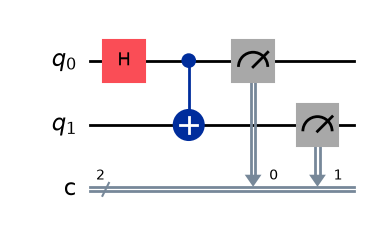

Counts: {'11': 4974, '00': 4974, '10': 20, '01': 32}


In [3]:
p1 = 1 - 0.999   # single-qubit error rate
p2 = 1 - 0.99    # two-qubit error rate

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p1, 1), ['h'])
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p2, 2), ['cx'])

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
display(qc.draw('mpl'))

nShots = 10000
counts = simulate_measurements(qc, shots=nShots, noise_model=noise_model)    
print('Counts:', counts)

### State preparation: impact of circuit depth  *(Book §11.1, Example 11.2)*

General state preparation needs $O(2^m)$ gates for $m$ qubits, so it is acutely noise-sensitive. Here we prepare the basis state $|1\rangle$ on registers of growing size $m=2,\ldots,8$, transpile to a fixed basis, count the single- and two-qubit gates ($n_1,n_2$), and compare the theoretical $F_\text{circuit}=(F_1)^{n_1}(F_2)^{n_2}$ against the measured fraction of correct outcomes. Fidelity falls off sharply as depth grows — the practical wall that limits NISQ algorithms and motivates error correction (Chapter 13 revisits state-prep cost).

m=2: n1=2, n2=1, F_theory=0.9880, F_measured=0.9918


c:\Users\ksure\anaconda3\envs\quantumTest\Lib\site-packages\qiskit\compiler\transpiler.py:276: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


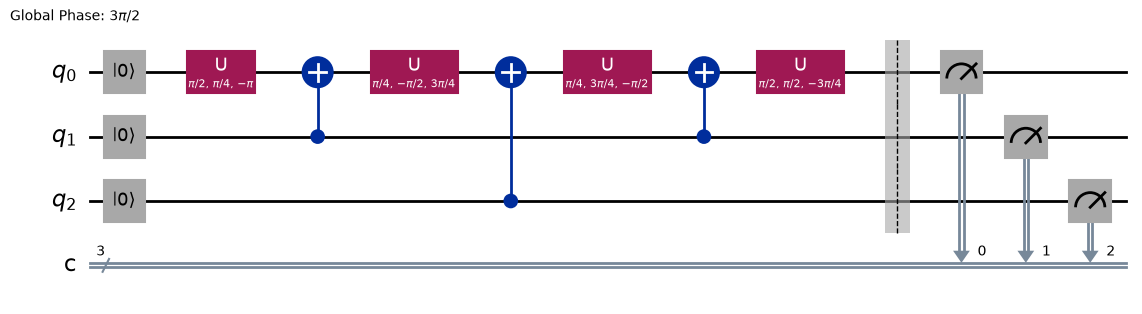

m=3: n1=4, n2=3, F_theory=0.9664, F_measured=0.9777
m=4: n1=8, n2=7, F_theory=0.9246, F_measured=0.9423
m=5: n1=16, n2=15, F_theory=0.8464, F_measured=0.8866
m=6: n1=32, n2=31, F_theory=0.7092, F_measured=0.7863
m=7: n1=64, n2=63, F_theory=0.4980, F_measured=0.6108
m=8: n1=128, n2=127, F_theory=0.2455, F_measured=0.4059


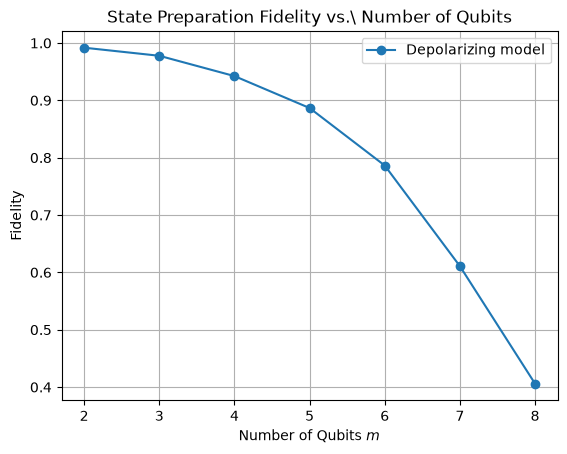

In [4]:
F1 = 0.999
F2 = 0.99
p1 = 1 - F1
p2 = 1 - F2
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p1, 1), ['u', 'rx', 'ry', 'rz', 'h', 'x', 'p'])
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p2, 2), ['cx'])

BASIS = ['cx', 'u', 'x', 'h', 'ry', 'rz', 'rx', 'p']
simulator       = AerSimulator(noise_model=noise_model)
nShots = 10000

m_list         = list(range(2, 9)) 
F_measured_list = []
F_theory_list   = []
F_hardware_list = []
for m in m_list:
    N = 2**m
    b = np.zeros(N)
    b[1] = 1.0
    
    qc = QuantumCircuit(m, m)
    qc.initialize(b, range(m))
    qc.barrier()
    qc.measure(range(m), range(m))
    
    qc_decomposed = qc.decompose(reps=3)
    qc_t = transpile(qc_decomposed, simulator,
                     basis_gates=BASIS)
    
    if (m == 3):
        display(qc_t.draw('mpl'))
    # Gate counts
    ops = qc_t.count_ops()
    n1  = sum(ops.get(g, 0) for g in
              ['u', 'rx', 'ry', 'rz', 'h', 'x', 'p'])
    n2  = ops.get('cx', 0)
    F_theory = (F1**n1) * (F2**n2)
    
    # Measured fidelity
    counts_noisy = simulator.run(qc_t, shots=nShots).result().get_counts()
    correct      = format(1, f'0{m}b')
    F_measured   = counts_noisy.get(correct, 0) / nShots
    
    F_theory_list.append(F_theory)
    F_measured_list.append(F_measured)
    print(f'm={m}: n1={n1}, n2={n2}, '
          f'F_theory={F_theory:.4f}, F_measured={F_measured:.4f}')
    
    # counts_hardware = runCircuitOnIBMQuantum(qc_t, shots=nShots, min_num_qubits=m)
    # F_hardware  = counts_hardware.get(correct, 0) / nShots
    # print(f'm={m}: F_hardware={F_hardware:.4f}')
    # F_hardware_list.append(F_hardware)

plt.figure()
plt.plot(m_list, F_measured_list, 'o-',  label='Depolarizing model')
#plt.plot(m_list, F_theory_list,   'r--', label=r'Bit-flip model')
#plt.plot(m_list, F_hardware_list, 's-', label='Hardware')
plt.xlabel('Number of Qubits $m$')
plt.ylabel('Fidelity')
plt.title('State Preparation Fidelity vs.\ Number of Qubits')
plt.legend()
plt.grid()
plt.show()

## Readout error  *(Book §11.3)*

Gate infidelity is not the only culprit: when a qubit is finally measured, the recorded classical bit can simply be wrong — a $|0\rangle$ read as $1$ and vice versa. This readout error is typically 1–2% per qubit, comparable to the two-qubit gate error. It is described by a $2\times2$ assignment matrix and added to the noise model directly. Here a *perfect* $X$ gate prepares $|1\rangle$, yet about 2% of shots misreport $|0\rangle$, giving $P(|1\rangle)\approx0.98$ — the error lives entirely in the measurement. Unlike gate errors, readout error can be largely undone in post-processing by calibrating and inverting the assignment matrix.

In [5]:
from qiskit_aer.noise import NoiseModel, ReadoutError

# 2% readout error on every qubit:
# P(report 1 | prepared 0) = P(report 0 | prepared 1) = 0.02
noise_model = NoiseModel()
noise_model.add_all_qubit_readout_error(
    ReadoutError([[0.98, 0.02], [0.02, 0.98]]))

# Prepare |1> with a PERFECT X gate, then measure
qc = QuantumCircuit(1, 1)
qc.x(0)
qc.measure(0, 0)

counts = simulate_measurements(qc, shots=10000, noise_model=noise_model)   
print("Counts:", counts)


Counts: {'0': 224, '1': 9776}
